In [4]:
from smode_import import *

In [5]:
# load gridded dopplerscatt
ds = xr.open_dataset('dopplerscatt_gridded.nc')
ds['time'] = pd.to_datetime(ds['time'])

# load dChldt
dChldt=xr.open_dataset('dChldt_sorted.nc')

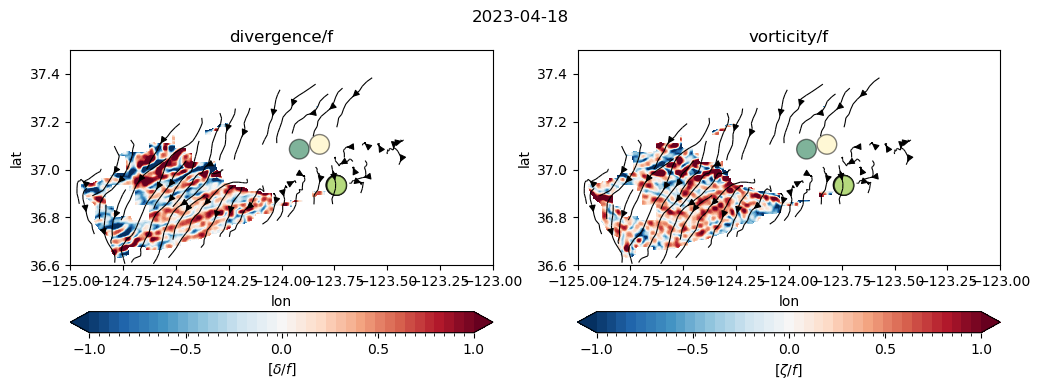

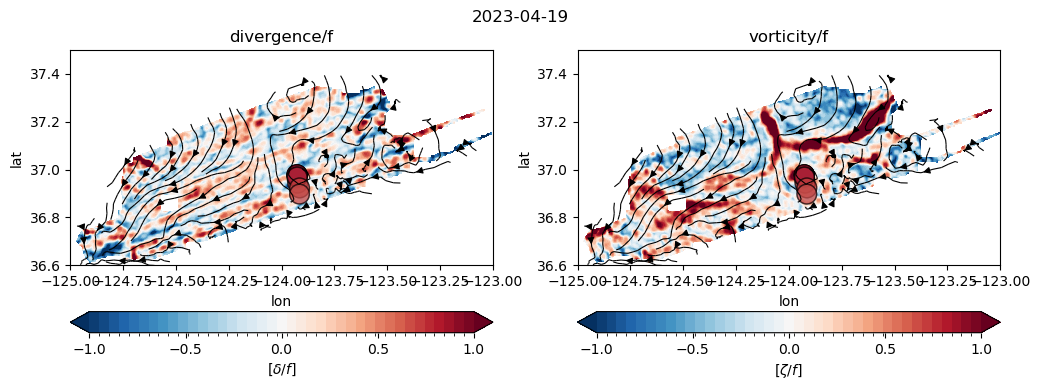

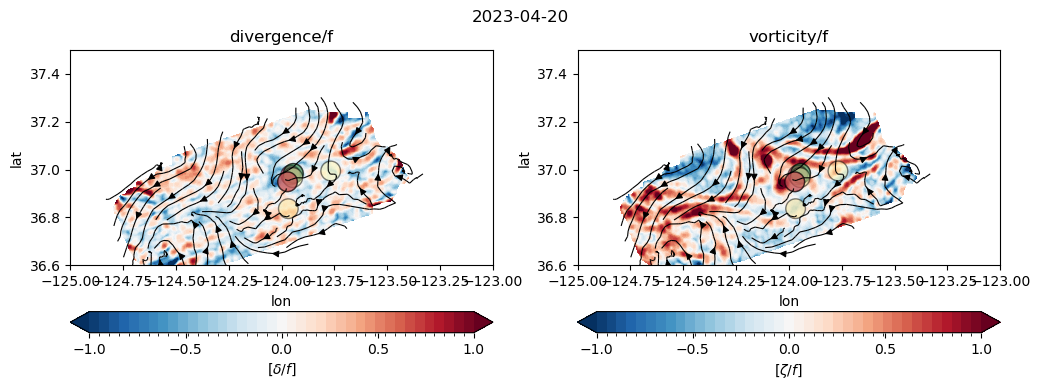

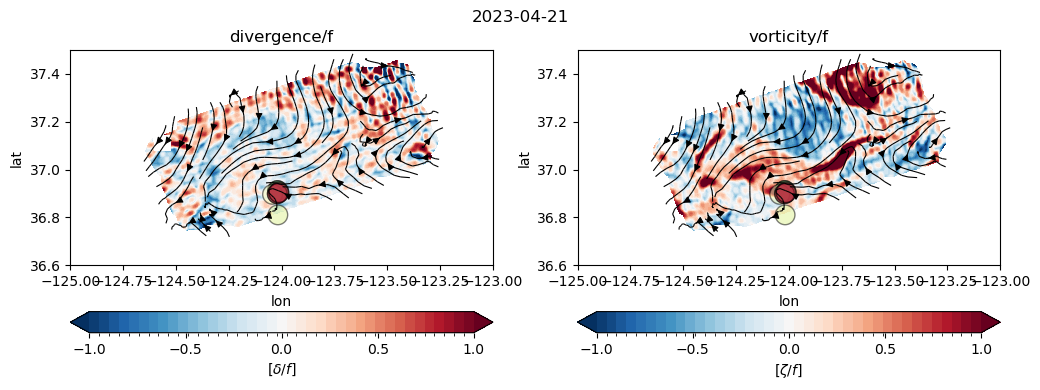

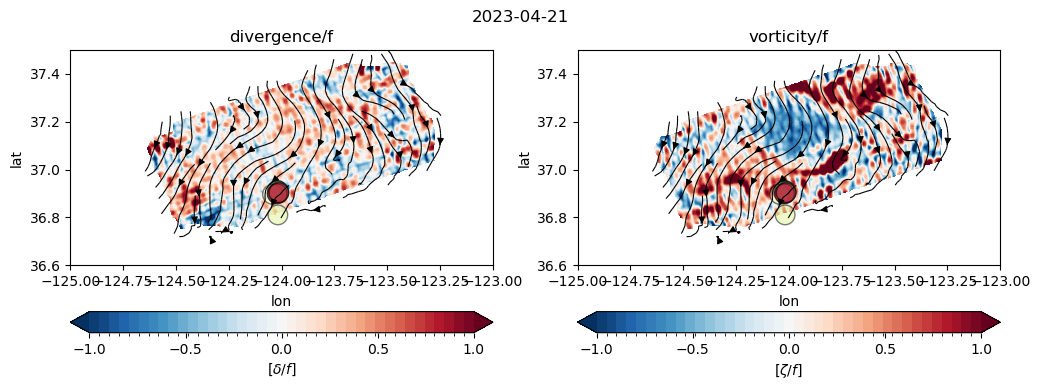

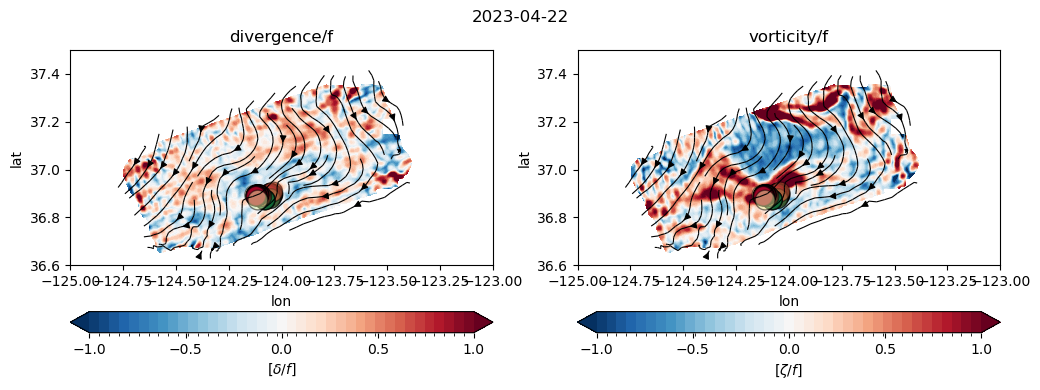

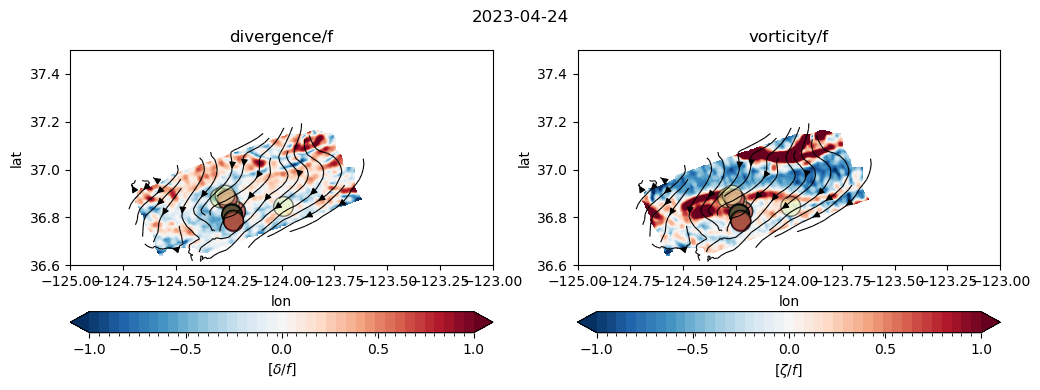

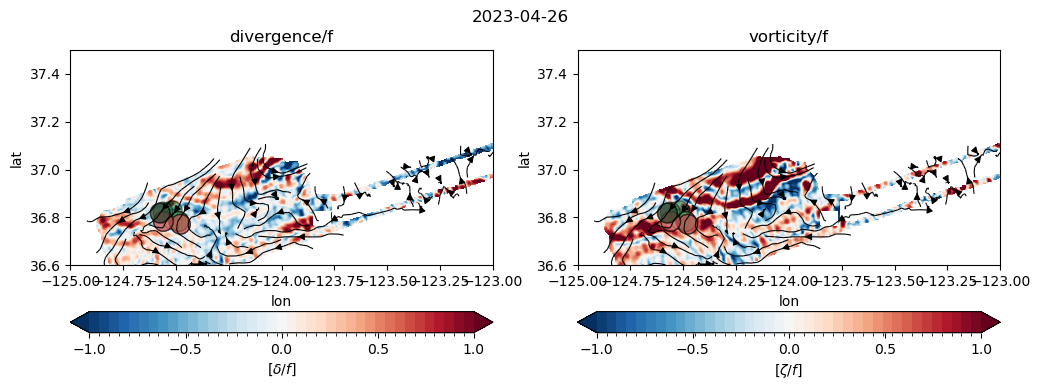

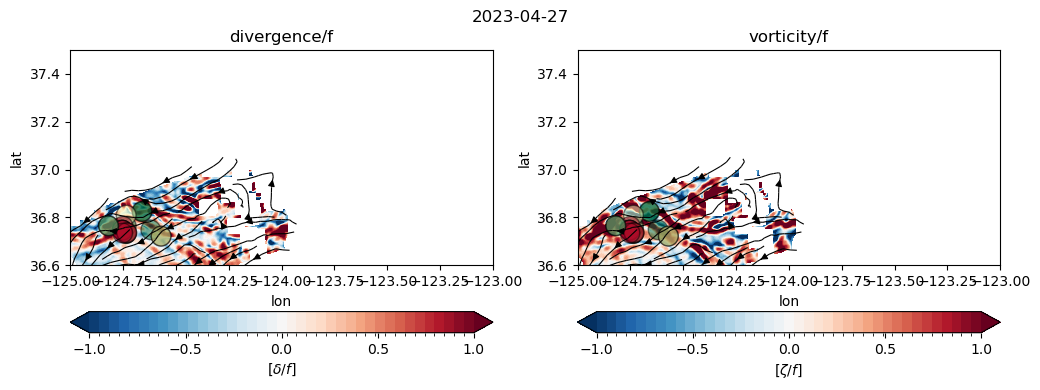

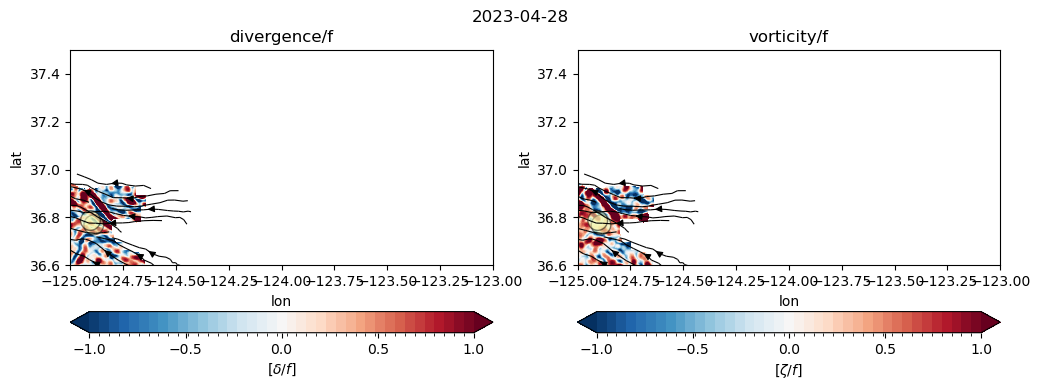

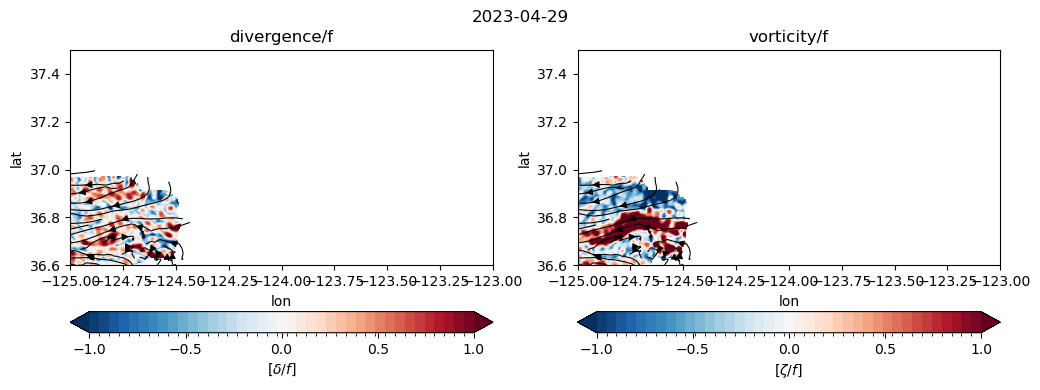

In [12]:
for i in range(10,ds.dims['time']):
    f = coriolis_parameter(ds.isel(time=i).lat.mean().values)
    time=ds.time.values[i]

    fig,ax=plt.subplots(1,2,figsize=(12,4))
    
    # divergence and vorticity
    levels=np.linspace(-1,1,40)
    (ds.divergence/f).isel(time=i).plot.contourf(ax=ax[0],levels=levels,cmap='RdBu_r',
                                                cbar_kwargs={'ticks': [-1,-0.5,0,0.5,1],
                                               'spacing': 'proportional',
                                                'label':r'[$\delta/f$]',
                                                'orientation': 'horizontal'})
    (ds.vorticity/f).isel(time=i).plot.contourf(ax=ax[1],levels=levels,cmap='RdBu_r',
                                                cbar_kwargs={'ticks': [-1,-0.5,0,0.5,1],
                                               'spacing': 'proportional',
                                                'label':r'[$\zeta/f$]',
                                                'orientation': 'horizontal'})
    ax[0].set_title('divergence/f'), ax[1].set_title('vorticity/f')
    
    for axis in ax:
        try:
            dChldt0 = dChldt.sel(time=str(time)[0:10])
            axis.scatter(dChldt0.lon,dChldt0.lat,s=200,c=dChldt0.dChldt,edgecolor='k',cmap='RdYlGn',vmin=-1e-4,vmax=1e-4,alpha=0.5)
        except KeyError: print('')
            #print(f"No dChldt values found for {time}.")
        # add velocity streamlines
        lons,lats=np.meshgrid(ds.lon,ds.lat)
        axis.streamplot(lons,lats,ds.u.isel(time=i),ds.v.isel(time=i),
                        color='k',density=3,linewidth=0.8,arrowsize=1)
        
        # zoom in
        axis.set_xlim(-125,-123); axis.set_ylim(36.6,37.5) #zoom
        #axis.set_xlim(-125,-124.2); axis.set_ylim(36.65,36.9) #zoom

    plt.suptitle(str(time)[0:10])
    plt.show()
    plt.close()

## Submesoscale kinematics vs dChldt

In [13]:
ds['time'] = pd.to_datetime(ds['time'])

div=[]
vor=[]
lat_ds=[]
lon_ds=[]
time_ds=[]

T=dChldt.dims['time']

n=0
for i in range(T):
    time = str(dChldt.time.values[i])
    lat  = dChldt.lat.isel(time=i).values
    lon  = dChldt.lon.isel(time=i).values
    
    target_time = np.datetime64(time)
    max_distance_seconds = 360 * 1 * 60  # 360 minutes * 60 seconds/minute = 6h
    time_diff = np.abs(ds.time.values - target_time)
    nearest_index = np.argmin(time_diff)
    if time_diff[nearest_index] <= np.timedelta64(max_distance_seconds, 's'):
        nearest_ds = ds.isel(time=nearest_index).sel(lat=lat, lon=lon, method='nearest')
        #print('found time!')
        time_ds.append(nearest_ds.time.values)
        lat_ds.append(nearest_ds.lat.values)
        lon_ds.append(nearest_ds.lon.values)
        div.append(nearest_ds.divergence.values)
        vor.append(nearest_ds.vorticity.values)
        n+=1

    # before method:
    #nearest_ds = ds.sel(time=time, lat=lat, lon=lon, method='nearest')

    div_array = xr.DataArray(div, dims=['time'], coords={'time': time_ds})
    vor_array = xr.DataArray(vor, dims=['time'], coords={'time': time_ds})
print(f'Found {n} times')

Found 89 times


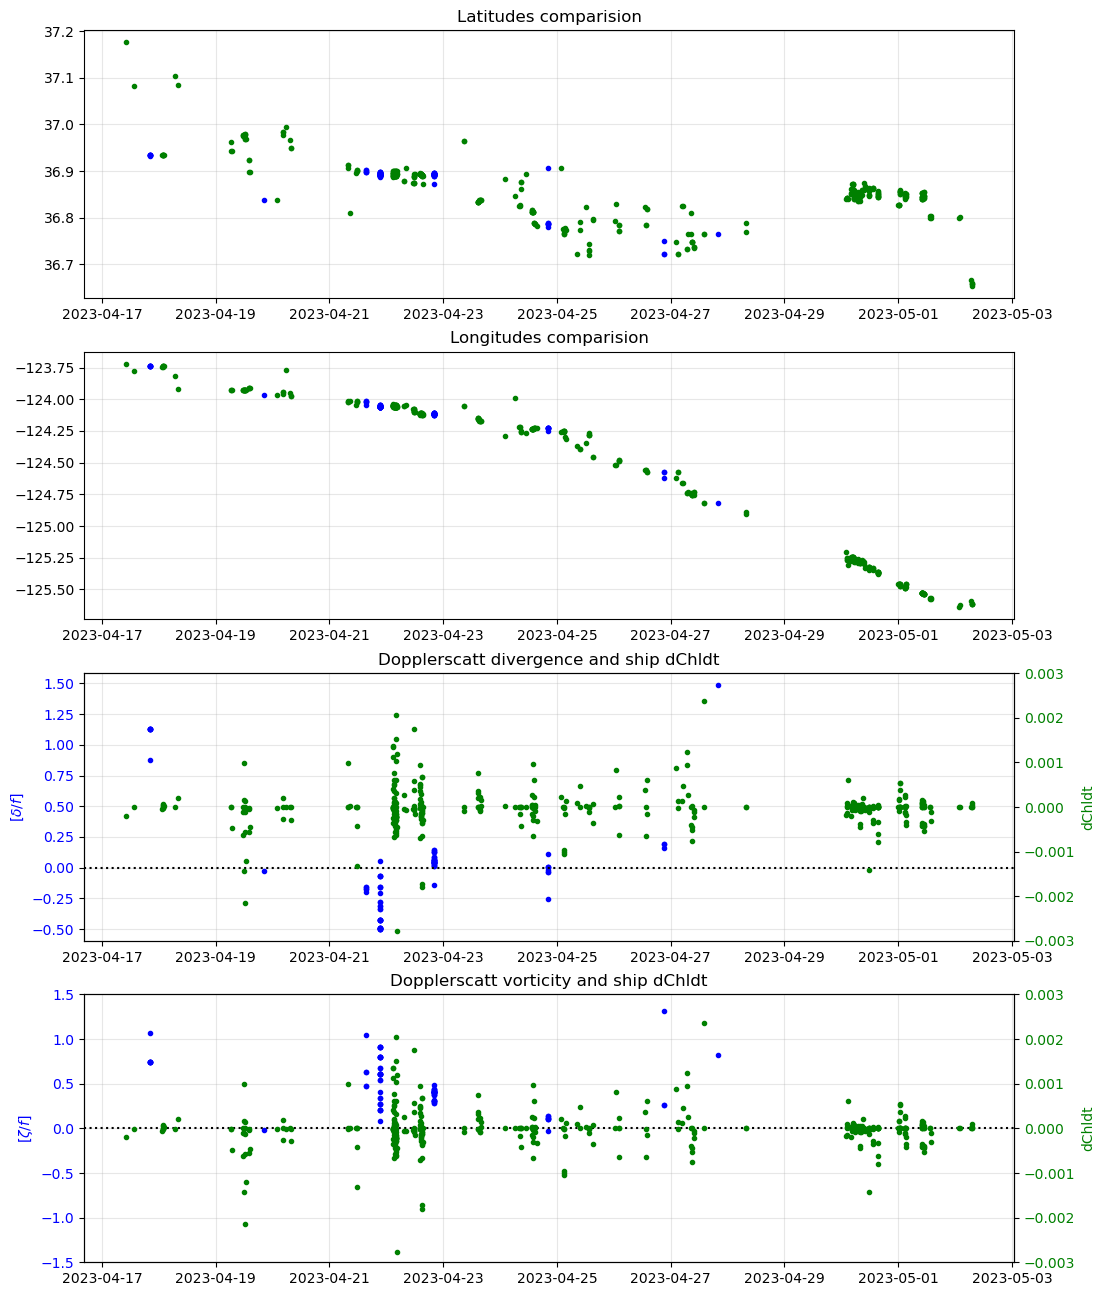

In [14]:
fig,ax=plt.subplots(4,1,figsize=(12,4*4))
# latitude
ax[0].plot(time_ds,lat_ds,'.b')
ax[0].plot(dChldt.time, dChldt.lat,'.g')
ax[0].set_title('Latitudes comparision')

# longitude
ax[1].plot(time_ds,lon_ds,'.b')
ax[1].plot(dChldt.time, dChldt.lon,'.g')
ax[1].set_title('Longitudes comparision')

# divergence
ax[2].plot(time_ds,div/f,'.b')
ax[2].set_ylabel(r'[$\delta/f$]', color='b')
ax[2].tick_params(axis='y', labelcolor='b')
ax[3].set_ylim(-1.5,1.5)

ax2=ax[2].twinx()
ax2.plot(dChldt.time, dChldt.dChldt,'.g')
ax2.set_ylabel('dChldt', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(-0.003,0.003)

ax[2].axhline(0, color='black', linestyle=':')
ax[2].set_title('Dopplerscatt divergence and ship dChldt')

# vorticity
ax[3].plot(time_ds,vor/f,'.b')
ax[3].set_ylabel(r'[$\zeta/f$]', color='b')
ax[3].tick_params(axis='y', labelcolor='b')
ax[3].axhline(0, color='black', linestyle=':')
ax[3].set_ylim(-1.5,1.5)

ax2=ax[3].twinx()
ax2.plot(dChldt.time, dChldt.dChldt,'.g')
ax2.set_ylabel('dChldt', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(-0.003,0.003)

ax[3].set_title('Dopplerscatt vorticity and ship dChldt')

from datetime import datetime
#t1=datetime.strptime('2023-04-17', '%Y-%m-%d')
#t2=datetime.strptime('2023-04-25', '%Y-%m-%d')
for axis in ax:
    axis.grid(alpha=0.3)
    #axis.set_xlim(t1,t2)
    
plt.show();

In [17]:
# resample time series to compare them

dt='30T'
dChldt_resampled = dChldt.dChldt.resample(time=dt).mean()
div_resampled    = div_array.resample(time=dt).mean()
vor_resampled    = vor_array.resample(time=dt).mean()

#plt.figure(figsize=(12,2))
#dChldt_resampled.plot(linestyle='None',marker='.')
#div_resampled.plot(linestyle='None',marker='.')
#vor_resampled.plot(linestyle='None',marker='.')
#plt.grid(alpha=0.3);

## 
t1,t2 = '2023-04-17T20:00','2023-04-27T00:00'

#plt.figure(figsize=(12,2))
#plt.plot(div_interpolated.sel(time=slice(t1,t2)).values, dChldt_interpolated.sel(time=slice(t1,t2)).values)
#plt.grid(alpha=0.3);

## Cyclonic Eddy on 2023/04/22

In [54]:
dChldtD = dChldt.sel(time=str(eddyD.time.values)[0:10])
dChldtD
#print(str(eddyD.time.values)[0:10])
#dChldt.sel(time='2023-04-19')

<xarray.Dataset>
Dimensions:  (time: 20)
Coordinates:
  * time     (time) datetime64[ns] 2023-04-19T06:34:27 ... 2023-04-19T14:20:46
Data variables:
    dChldt   (time) float64 -3.455e-06 -3.957e-06 ... -1.922e-05 -0.0004584
    lon      (time) float64 -123.9 -123.9 -123.9 -123.9 ... -123.9 -123.9 -123.9
    lat      (time) float64 36.96 36.94 36.94 36.98 ... 36.92 36.92 36.9 36.9

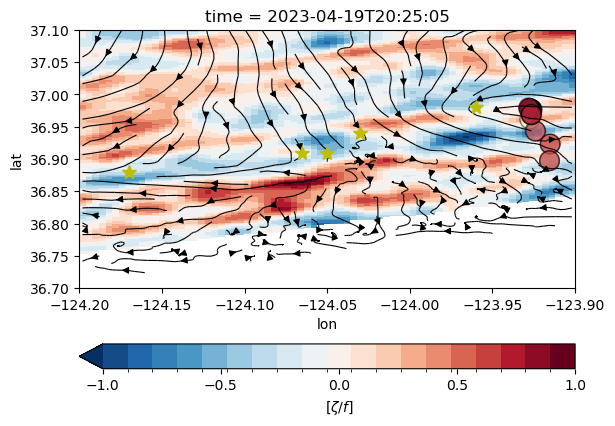

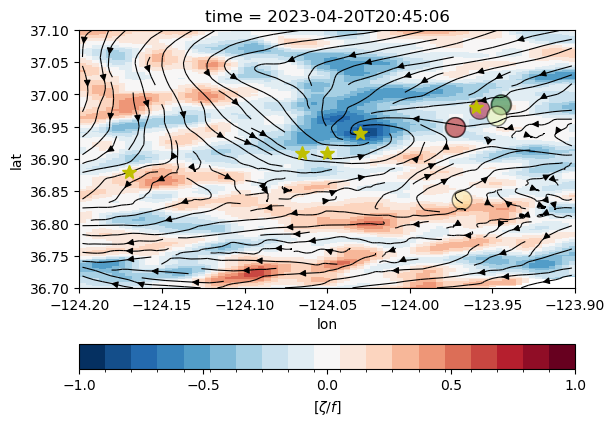

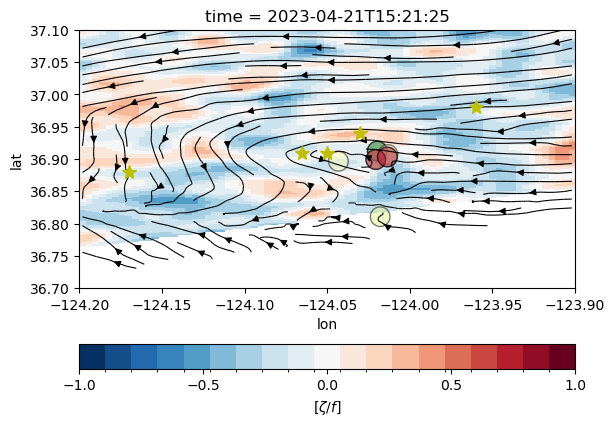

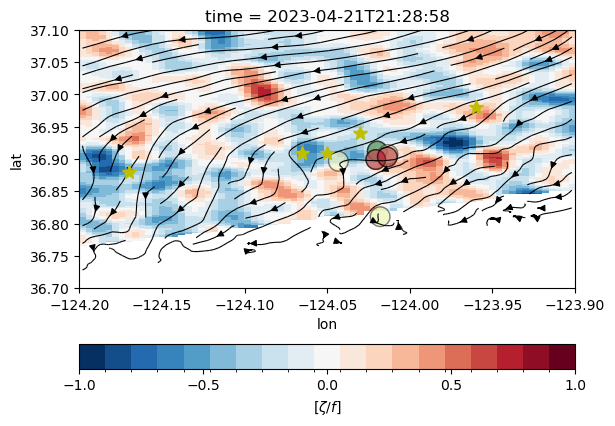

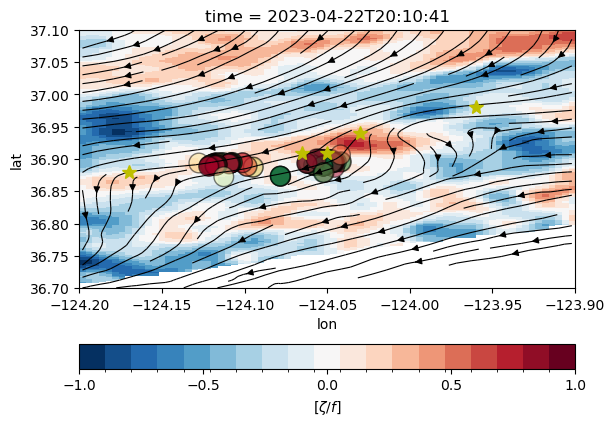

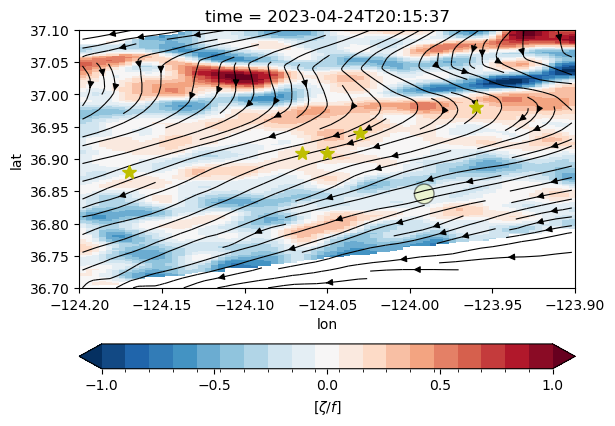

In [62]:
tstart='2023-04-19'
tend='2023-04-24'

eddy = ds.sel(time=slice(tstart,tend)).sel(lat=slice(36.7,37.1),lon=slice(-124.2,-123.9))
    
for it in range(eddy.dims['time']):
    eddyD=eddy.isel(time=it)
    
    f=coriolis_parameter(eddyD.lat.mean().values)
    levels=np.linspace(-1,1,20)
    (eddyD.divergence/f).plot.pcolormesh(levels=levels,cbar_kwargs={'ticks': [-1,-0.5,0,0.5,1],
                                                   'spacing': 'proportional',
                                                    'label':r'[$\zeta/f$]',
                                                    'orientation': 'horizontal'})
    
    # add dChldt
    dChldtD = dChldt.sel(time=str(eddyD.time.values)[0:10])
    plt.scatter(dChldtD.lon,dChldtD.lat,s=200,c=dChldtD.dChldt,edgecolor='k',cmap='RdYlGn',vmin=-1e-4,vmax=1e-4,alpha=0.5)
    
    # add current streamlines
    lons,lats=np.meshgrid(eddyD.lon,eddyD.lat)
    plt.streamplot(lons,lats,eddyD.u,eddyD.v,
                    color='k',density=1,linewidth=0.8,arrowsize=1,
                   broken_streamlines=True)
    
    plt.plot(-123.96,36.98,'*y',markersize=10) # april 19
    plt.plot(-124.03,36.94,'*y',markersize=10) # april 20
    plt.plot(-124.05,36.91,'*y',markersize=10) # april 21T15
    plt.plot(-124.065,36.91,'*y',markersize=10) # april 21T21
    plt.plot(-124.17,36.88,'*y',markersize=10) # april 22
    plt.plot(-124.41,36.83,'*y',markersize=10) # april 24
    
    #plt.xlim(-125.0,-123.2); plt.ylim(36.55,37.5)
    #plt.xlim(-124.5,-123.8);plt.ylim(36.5,37.2)
    plt.show()


In [ ]:
# PRISM


In [ ]:
# mesoscale for that eddy
# what was the mechanism formation of that eddy